In [1]:
from typing import TypedDict

class State(TypedDict):
    question: str
    reseach: str
    web_search: str
    memory: str
    final_answer: str

In [3]:
def research_node(state: State):
    print("병렬1: research_node 전문 연구 중...")
    return {"research": f"[연구] {state['question']}에 대한 깊이 있는 분석"}

def web_search_node(state: State):
    print("병렬2: web_search_node 웹 검색 중...")
    return {"web_search": f"[연구] {state['question']}에 대한 최신 정보 검색"}

def recall_memory_node(state: State):
    print("병렬3: recall_memory_node 과거 대화 기억 불러오는 중...")
    return {"memory": "이전 대화에서 비슷한 질문이 있었음"}

In [7]:
def combine_node(state: State):
    print("최종: combine_node 모든 결과를 통합")
    combined = (
        f"""질문: {state["question"]}
- 연구: {state.get('research', '')}
- 웹 검색: {state.get('web_search', '')}
- 메모리: {state.get('memory', '')}"""
    )

    return {"final_answer": combined}

In [8]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

graph_builder.add_node("research", research_node)
graph_builder.add_node("web_search", web_search_node)
graph_builder.add_node("recall_memory", recall_memory_node)
graph_builder.add_node("combine", combine_node)

graph_builder.add_edge(START, "research")
graph_builder.add_edge(START, "web_search")
graph_builder.add_edge(START, "recall_memory")

graph_builder.add_edge("research", "combine")
graph_builder.add_edge("web_search", "combine")
graph_builder.add_edge("recall_memory", "combine")

graph_builder.add_edge("combine", END)

graph = graph_builder.compile()

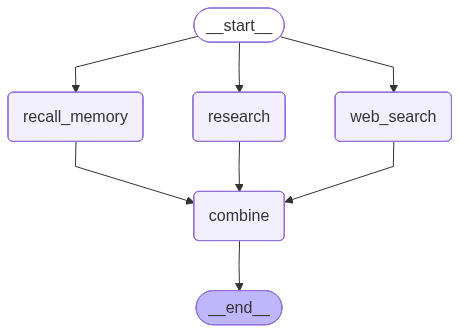

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
graph.invoke({"question": "Langgraph란?"})

병렬3: recall_memory_node 과거 대화 기억 불러오는 중...
병렬1: research_node 전문 연구 중...
병렬2: web_search_node 웹 검색 중...
최종: combine_node 모든 결과를 통합


{'question': 'Langgraph란?',
 'web_search': '[연구] Langgraph란?에 대한 최신 정보 검색',
 'memory': '이전 대화에서 비슷한 질문이 있었음',
 'final_answer': '질문: Langgraph란?\n- 연구: \n- 웹 검색: [연구] Langgraph란?에 대한 최신 정보 검색\n- 메모리: 이전 대화에서 비슷한 질문이 있었음'}